# Product Feature Experimentation & Conversion Optimization
### Product Analytics Case Study · One-Tap Checkout A/B Test

**Role:** Product Analyst | **Domain:** Consumer payments | **Experiment ID:** `EXP_CHECKOUT_2026_01`

> **Data disclosure:** This portfolio case study uses fully synthetic data. The experiment and its effects are simulated for analytical practice. Results must not be presented as evidence about a real company or product.

## Executive question

The product team is considering a one-tap checkout experience. My task is to determine whether it changes purchase conversion, understand where users move through the checkout funnel, check relevant guardrails, identify whether effects differ across user groups, and communicate a decision with appropriate uncertainty.

I will work in the order I would use on a product analytics assignment: define the decision → validate the experiment and data → define metrics → quantify the primary outcome → diagnose the funnel → investigate segments and guardrails → document limitations → provide a measured recommendation.


## 1. Decision framing and analysis plan

**Decision to support:** whether the product team should continue testing, consider a controlled rollout, or avoid rollout pending more evidence.

**Hypothesis:** one-tap checkout may reduce friction and improve completed purchase conversion.

**Primary metric:** user-level purchase conversion (`converted`), measured across all assigned users.

**Secondary metrics:** checkout-start rate, payment-attempt rate, revenue per assigned user, and purchases per assigned user.

**Guardrails included in this synthetic dataset:** payment failure and support contact indicators. A real launch would also require latency, refunds, fraud, accessibility, and customer complaints.

**Analysis unit:** user, because assignment is randomized at user level. I will not treat individual events as independent experiment observations.

**Pre-analysis caveats:** the synthetic data-generating process intentionally embeds modest treatment effects. I will still calculate the results as if reviewing an experiment, but I will label them simulated and avoid claiming causal evidence about a real product.


## 2. Load data and understand table grain

The project contains four tables:
- `users`: one row per user profile.
- `experiment_assignments`: one row per randomized user assignment.
- `experiment_metrics`: one row per assigned user with outcome flags and value metrics.
- `product_events`: event-level behavioral log, with multiple rows per user.

I start by confirming row counts, date ranges, and the unique-key grain before joining tables.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, norm
from IPython.display import display

DATA_DIR = Path("../data")
REPORT_DIR = Path("../reports")
REPORT_DIR.mkdir(exist_ok=True)

users = pd.read_csv(DATA_DIR/"users.csv", parse_dates=["signup_date"])
assignments = pd.read_csv(DATA_DIR/"experiment_assignments.csv", parse_dates=["assignment_date"])
events = pd.read_csv(DATA_DIR/"product_events.csv", parse_dates=["event_timestamp"])
metrics = pd.read_csv(DATA_DIR/"experiment_metrics.csv")

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

inventory = pd.DataFrame([
    ["users", len(users), users["user_id"].nunique(), "one row per user"],
    ["experiment_assignments", len(assignments), assignments["user_id"].nunique(), "one row per assigned user"],
    ["experiment_metrics", len(metrics), metrics["user_id"].nunique(), "one row per user outcome"],
    ["product_events", len(events), events["event_id"].nunique(), "one row per event"],
], columns=["table", "rows", "unique_key_count", "expected_grain"])
display(inventory)
print("Assignment date range:", assignments["assignment_date"].min().date(), "to", assignments["assignment_date"].max().date())
print("Event timestamp range:", events["event_timestamp"].min(), "to", events["event_timestamp"].max())


,table,rows,unique_key_count,expected_grain
0,users,50000,50000,one row per user
1,experiment_assignments,50000,50000,one row per assigned user
2,experiment_metrics,50000,50000,one row per user outcome
3,product_events,293364,293364,one row per event


Assignment date range: 2026-07-01 to 2026-07-28
Event timestamp range: 2026-07-01 00:00:00 to 2026-07-28 01:17:00


## 3. Data quality and experiment integrity

A polished experiment readout starts with trust in the data. I check key uniqueness, missingness, join coverage, allowed categories, binary metric values, and assignment balance. A sample-ratio mismatch (SRM) check compares observed group sizes with the intended 50/50 split. A non-significant SRM test does not prove randomization was correct; it is one diagnostic.


In [2]:
quality = {
    "duplicate_user_ids_in_users": int(users.user_id.duplicated().sum()),
    "duplicate_user_assignments": int(assignments.user_id.duplicated().sum()),
    "duplicate_user_metric_rows": int(metrics.user_id.duplicated().sum()),
    "duplicate_event_ids": int(events.event_id.duplicated().sum()),
    "events_without_profile": int((~events.user_id.isin(users.user_id)).sum()),
    "assignments_without_metrics": int((~assignments.user_id.isin(metrics.user_id)).sum()),
    "metrics_without_assignment": int((~metrics.user_id.isin(assignments.user_id)).sum()),
}
display(pd.Series(quality, name="count").to_frame())

print("Missing values per table")
display(pd.concat({
    "users": users.isna().sum(),
    "assignments": assignments.isna().sum(),
    "metrics": metrics.isna().sum(),
    "events": events.isna().sum()
}, axis=1).fillna(0).astype(int))

binary_cols = ["checkout_started","payment_attempted","payment_completed","converted","payment_failure","support_contact"]
binary_validation = pd.DataFrame({
    col: [sorted(metrics[col].dropna().unique().tolist()), bool(metrics[col].dropna().isin([0,1]).all())]
    for col in binary_cols
}, index=["observed_values","only_0_or_1"])
display(binary_validation)


,count
duplicate_user_ids_in_users,0
duplicate_user_assignments,0
duplicate_user_metric_rows,0
duplicate_event_ids,0
events_without_profile,0
assignments_without_metrics,0
metrics_without_assignment,0


Missing values per table


,users,assignments,metrics,events
user_id,0,0,0,0
age_group,0,0,0,0
country,0,0,0,0
signup_date,0,0,0,0
customer_segment,0,0,0,0
device_type,0,0,0,0
experiment_id,0,0,0,0
experiment_group,0,0,0,0
assignment_date,0,0,0,0
feature_variant,0,0,0,0


,checkout_started,payment_attempted,payment_completed,converted,payment_failure,support_contact
observed_values,"[0, 1]","[0, 1]","[0, 1]","[0, 1]","[0, 1]","[0, 1]"
only_0_or_1,True,True,True,True,True,True


In [3]:
group_counts = assignments["experiment_group"].value_counts().reindex(["control","treatment"])
display(group_counts.rename("assigned_users").to_frame())
observed = group_counts.to_numpy()
expected = np.array([len(assignments)/2, len(assignments)/2])
srm_chi2 = ((observed-expected)**2/expected).sum()
srm_p = 1 - __import__("scipy").stats.chi2.cdf(srm_chi2, df=1)
print(f"50/50 sample-ratio check: chi-square={srm_chi2:.3f}, p-value={srm_p:.4f}")


,assigned_users
experiment_group,
control,24904
treatment,25096


50/50 sample-ratio check: chi-square=0.737, p-value=0.3905


### 3.1 Build a trusted user-level analysis table

I merge assignment, outcomes, and user attributes with explicit one-to-one validation. This avoids accidental row multiplication. I keep the event table separate because it has many rows per user.


In [4]:
experiment = (
    assignments[["user_id","experiment_id","experiment_group","assignment_date","feature_variant"]]
    .merge(metrics, on=["user_id","experiment_group"], how="left", validate="one_to_one", indicator=True)
)
print("Outcome join coverage:")
display(experiment["_merge"].value_counts().rename_axis("status").to_frame("users"))
experiment = experiment.drop(columns="_merge").merge(
    users[["user_id","age_group","country","customer_segment","device_type","signup_date"]],
    on="user_id", how="left", validate="one_to_one"
)
print("Analysis rows:", f"{len(experiment):,}", "| unique users:", f"{experiment.user_id.nunique():,}")


Outcome join coverage:


,users
status,
both,50000
left_only,0
right_only,0


Analysis rows: 50,000 | unique users: 50,000


## 4. Metric definitions and baseline scorecard

The denominator for conversion and funnel reach is all assigned users, preserving the randomized comparison. I also report stage-to-stage progression separately because it answers a different question.

| KPI | Calculation | Interpretation |
|---|---|---|
| Purchase conversion | Converted users / assigned users | Primary success metric |
| Checkout-start rate | Checkout starters / assigned users | Purchase intent |
| Payment-attempt rate | Payment attempts / assigned users | Progression to payment |
| Revenue per assigned user | Sum of revenue / assigned users | Value generated per randomized user |
| Payment failure rate | Users with failure / assigned users | Guardrail |
| Support contact rate | Users with support contact / assigned users | Guardrail |

Metric definitions should be agreed with product, engineering, and finance before a real experiment begins.


In [5]:
def summarize_group(frame):
    return frame.groupby("experiment_group").agg(
        assigned_users=("user_id","nunique"),
        checkout_start_rate=("checkout_started","mean"),
        payment_attempt_rate=("payment_attempted","mean"),
        conversion_rate=("converted","mean"),
        revenue_per_user=("revenue","mean"),
        avg_purchases_per_user=("purchase_count","mean"),
        payment_failure_rate=("payment_failure","mean"),
        support_contact_rate=("support_contact","mean"),
        total_revenue=("revenue","sum"),
    ).reindex(["control","treatment"]).reset_index()

scorecard = summarize_group(experiment)
display(scorecard)


,experiment_group,assigned_users,checkout_start_rate,payment_attempt_rate,conversion_rate,revenue_per_user,avg_purchases_per_user,payment_failure_rate,support_contact_rate,total_revenue
0,control,24904,0.6616,0.4828,0.3370,16.6500,0.4413,0.0371,0.0349,"414,650.5700"
1,treatment,25096,0.7131,0.5393,0.3896,19.0858,0.5133,0.0371,0.0363,"478,976.1500"


## 5. Primary outcome: conversion difference and uncertainty

I report the absolute difference in percentage points and relative lift. For the difference in two proportions, I calculate a 95% confidence interval using the unpooled standard error. I also show a two-sided chi-square test. These are conventional large-sample methods; for sparse outcomes or complex assignment designs, the test should be adapted.

A p-value is not the probability that the feature works. I will interpret the interval, effect size, data quality, and business context together.


In [6]:
g = scorecard.set_index("experiment_group")
n_c, n_t = int(g.loc["control","assigned_users"]), int(g.loc["treatment","assigned_users"])
p_c, p_t = float(g.loc["control","conversion_rate"]), float(g.loc["treatment","conversion_rate"])
diff = p_t - p_c
rel_lift = diff/p_c if p_c else np.nan
se_diff = np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)
ci_low, ci_high = diff-1.96*se_diff, diff+1.96*se_diff
contingency = pd.crosstab(experiment["experiment_group"],experiment["converted"]).reindex(
    index=["control","treatment"], columns=[0,1], fill_value=0
)
chi2, p_value, dof, expected_counts = chi2_contingency(contingency)
primary_readout = pd.DataFrame({
    "control_conversion":[p_c],
    "treatment_conversion":[p_t],
    "absolute_lift_pp":[diff*100],
    "relative_lift_pct":[rel_lift*100],
    "ci_95_low_pp":[ci_low*100],
    "ci_95_high_pp":[ci_high*100],
    "chi_square_p_value":[p_value],
    "control_users":[n_c],
    "treatment_users":[n_t]
})
display(primary_readout)
print("Outcome counts:")
display(contingency)


,control_conversion,treatment_conversion,absolute_lift_pp,relative_lift_pct,ci_95_low_pp,ci_95_high_pp,chi_square_p_value,control_users,treatment_users
0,0.3370,0.3896,5.2650,15.6243,4.4232,6.1068,0.0000,24904,25096


Outcome counts:


converted,0,1
experiment_group,,
control,16512,8392
treatment,15318,9778


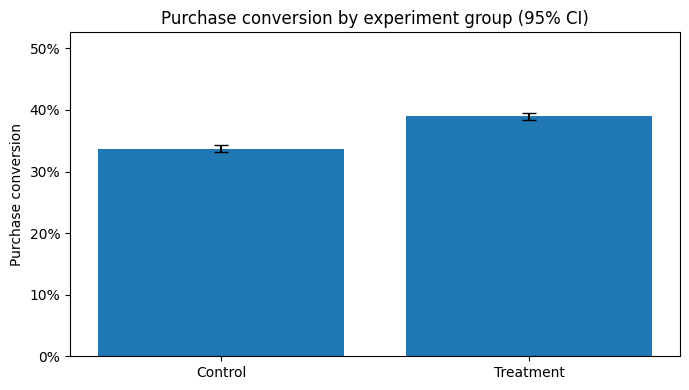

In [7]:
rates = [p_c,p_t]
labels = ["Control","Treatment"]
errors = [[p_c-(p_c-1.96*np.sqrt(p_c*(1-p_c)/n_c)), p_t-(p_t-1.96*np.sqrt(p_t*(1-p_t)/n_t))],
          [(p_c+1.96*np.sqrt(p_c*(1-p_c)/n_c))-p_c, (p_t+1.96*np.sqrt(p_t*(1-p_t)/n_t))-p_t]]
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(labels, rates, yerr=np.array(errors), capsize=5)
ax.set_ylim(0, max(rates)*1.35)
ax.set_ylabel("Purchase conversion")
ax.set_title("Purchase conversion by experiment group (95% CI)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
plt.tight_layout()
plt.show()


## 6. Funnel diagnosis

I compare the share of assigned users who reached checkout, attempted payment, and completed a purchase. I then calculate stage-to-stage progression. Looking at both views helps separate changes in user entry into checkout from changes in payment completion.

The flags are generated at user level. They are not a validated event-sequence funnel; a production event funnel would require ordered timestamps, exposure checks, session rules, and deduplication.


,checkout_started,payment_attempted,payment_completed
experiment_group,,,
control,0.6616,0.4828,0.3370
treatment,0.7131,0.5393,0.3896


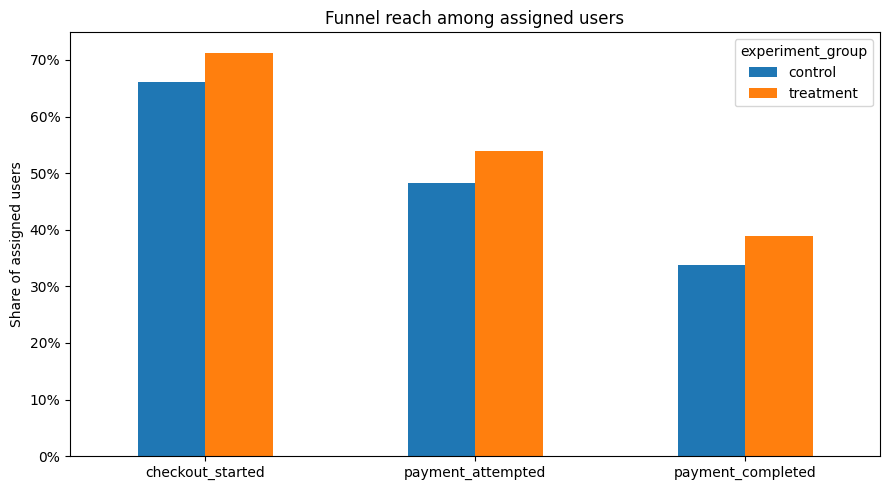

,checkout_to_payment_attempt,payment_attempt_to_complete
experiment_group,,
control,0.7297,0.6980
treatment,0.7564,0.7224


In [8]:
funnel_cols=["checkout_started","payment_attempted","payment_completed"]
funnel_reach=experiment.groupby("experiment_group")[funnel_cols].mean().reindex(["control","treatment"])
display(funnel_reach)
ax=funnel_reach.T.plot(kind="bar",figsize=(9,5),rot=0,title="Funnel reach among assigned users")
ax.set_ylabel("Share of assigned users")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
plt.tight_layout(); plt.show()

stage_rows=[]
for grp, frame in experiment.groupby("experiment_group"):
    n_checkout=frame.checkout_started.sum()
    n_attempt=frame.payment_attempted.sum()
    n_complete=frame.payment_completed.sum()
    stage_rows.append({"experiment_group":grp,
        "checkout_to_payment_attempt":n_attempt/n_checkout if n_checkout else np.nan,
        "payment_attempt_to_complete":n_complete/n_attempt if n_attempt else np.nan})
stage_rates=pd.DataFrame(stage_rows).set_index("experiment_group").reindex(["control","treatment"])
display(stage_rates)


## 7. Guardrail metrics

A conversion gain is not enough if the feature creates payment failures or increases support demand. I compare payment failure and support contact rates by assigned group. In a real launch, I would add pre-agreed non-inferiority thresholds and monitor these metrics during rollout rather than relying only on a single end-of-test comparison.


In [9]:
guardrails=scorecard[["experiment_group","payment_failure_rate","support_contact_rate"]].copy()
display(guardrails)
guardrail_diff = pd.DataFrame({
    "metric":["payment_failure_rate","support_contact_rate"],
    "control":[g.loc["control","payment_failure_rate"],g.loc["control","support_contact_rate"]],
    "treatment":[g.loc["treatment","payment_failure_rate"],g.loc["treatment","support_contact_rate"]]
})
guardrail_diff["difference_pp"]=(guardrail_diff["treatment"]-guardrail_diff["control"])*100
display(guardrail_diff)


,experiment_group,payment_failure_rate,support_contact_rate
0,control,0.0371,0.0349
1,treatment,0.0371,0.0363


,metric,control,treatment,difference_pp
0,payment_failure_rate,0.0371,0.0371,-0.0085
1,support_contact_rate,0.0349,0.0363,0.1366


## 8. Segment analysis: device, customer type, and geography

I compare group outcomes within selected segments and show the number of users in each cell. These cuts are exploratory, not independent confirmatory experiments. I avoid declaring a subgroup “the winner” based on a rate alone; sample size, uncertainty, multiple comparisons, and plausible product mechanisms all matter.


Conversion by device_type


,device_type,experiment_group,users,conversion_rate,revenue_per_user
0,Desktop,control,6338,0.3359,16.4452
1,Desktop,treatment,6261,0.3931,18.9598
2,Mobile,control,17379,0.3370,16.5936
3,Mobile,treatment,17528,0.3884,19.0610
4,Tablet,control,1187,0.3420,18.5679
5,Tablet,treatment,1307,0.3894,20.0216


Conversion by customer_segment


,customer_segment,experiment_group,users,conversion_rate,revenue_per_user
0,Active,control,12365,0.3560,17.7001
1,Active,treatment,12536,0.4075,19.9876
2,New,control,7051,0.2805,13.7058
3,New,treatment,7101,0.3288,15.8016
4,Returning,control,5488,0.3666,18.0665
5,Returning,treatment,5459,0.4277,21.2866


Conversion by country


,country,experiment_group,users,conversion_rate,revenue_per_user
0,Australia,control,1901,0.3451,16.6471
1,Australia,treatment,2047,0.3894,20.1844
2,Canada,control,2277,0.3224,16.1958
3,Canada,treatment,2297,0.3983,19.2974
4,India,control,11795,0.3368,16.6658
5,India,treatment,11778,0.3851,18.6516
6,United Kingdom,control,4695,0.3461,17.1153
7,United Kingdom,treatment,4752,0.3878,18.5691
8,United States,control,4236,0.3314,16.3354
9,United States,treatment,4222,0.3996,20.2307


Conversion by age_group


,age_group,experiment_group,users,conversion_rate,revenue_per_user
0,18-24,control,4566,0.3417,16.7085
1,18-24,treatment,4620,0.3935,19.0208
2,25-34,control,9155,0.3345,16.6348
3,25-34,treatment,9287,0.3860,19.0876
4,35-44,control,5733,0.3410,16.9579
5,35-44,treatment,5698,0.3893,18.6664
6,45-54,control,3447,0.3409,16.3757
7,45-54,treatment,3498,0.3959,20.1302
8,55+,control,2003,0.3195,16.1764
9,55+,treatment,1993,0.3874,18.5937


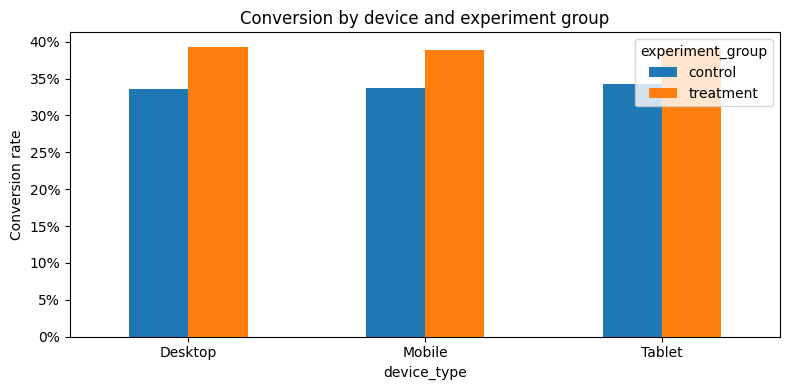

In [10]:
segment_tables={}
for dim in ["device_type","customer_segment","country","age_group"]:
    out=(experiment.groupby([dim,"experiment_group"])
         .agg(users=("user_id","nunique"),conversion_rate=("converted","mean"),
              revenue_per_user=("revenue","mean"))
         .reset_index())
    segment_tables[dim]=out
    print(f"Conversion by {dim}")
    display(out)

device_pivot=segment_tables["device_type"].pivot(index="device_type",columns="experiment_group",values="conversion_rate").reindex(columns=["control","treatment"])
ax=device_pivot.plot(kind="bar",figsize=(8,4),rot=0,title="Conversion by device and experiment group")
ax.set_ylabel("Conversion rate"); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_:f"{y:.0%}"))
plt.tight_layout(); plt.show()


## 9. Revenue and customer value

I review revenue per assigned user, median revenue, and purchase frequency. Revenue is usually skewed, so the mean can be influenced by a small number of large orders. For a decision-grade real experiment, I would consider bootstrap confidence intervals and longer-term retention/value outcomes.


,users,total_revenue,revenue_per_user,median_revenue_per_user,avg_purchase_count
experiment_group,,,,,
control,24904,"414,650.5700",16.6500,0.0000,0.4413
treatment,25096,"478,976.1500",19.0858,0.0000,0.5133


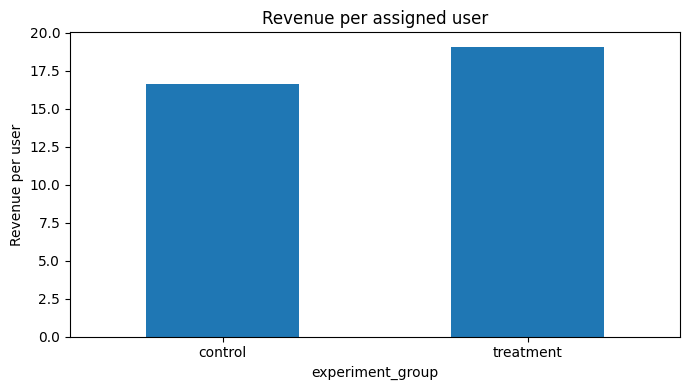

In [11]:
revenue_summary=experiment.groupby("experiment_group").agg(
    users=("user_id","nunique"), total_revenue=("revenue","sum"),
    revenue_per_user=("revenue","mean"), median_revenue_per_user=("revenue","median"),
    avg_purchase_count=("purchase_count","mean")
).reindex(["control","treatment"])
display(revenue_summary)
ax=revenue_summary["revenue_per_user"].plot(kind="bar",figsize=(7,4),rot=0,title="Revenue per assigned user")
ax.set_ylabel("Revenue per user"); plt.tight_layout(); plt.show()


## 10. Event-level behavior

The event log is used to understand product activity, not as the experiment's independent unit. I summarize event volume and distinct users by event type, then review activity over time. Counts can exceed user counts because a user can perform multiple events.


,event_count,unique_users
event_name,,
app_open,83291,50000
product_view,83220,50000
checkout_started,34372,34372
feature_clicked,33591,24532
payment_attempted,25558,25558
purchase_completed,18170,18170
one_tap_feature_view,15162,15162


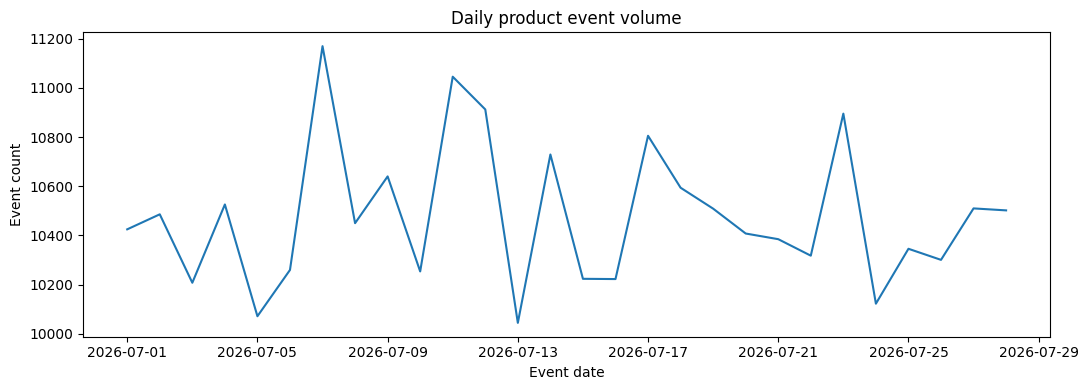

In [12]:
event_summary=events.groupby("event_name").agg(
    event_count=("event_id","count"), unique_users=("user_id","nunique")
).sort_values("event_count",ascending=False)
display(event_summary)
daily=events.assign(event_date=events.event_timestamp.dt.date).groupby("event_date").size()
ax=daily.plot(figsize=(11,4),title="Daily product event volume")
ax.set_xlabel("Event date"); ax.set_ylabel("Event count"); plt.tight_layout(); plt.show()


## 11. Product analyst interpretation

Use the computed outputs above to write a concise readout. A defensible conclusion should include:
- **What happened:** control and treatment conversion rates, absolute lift, relative lift, and confidence interval.
- **How certain we are:** p-value, interval, sample-ratio check, and data quality.
- **Where it happened:** funnel stage movement and carefully qualified segment patterns.
- **Business impact:** revenue per assigned user and guardrail changes.
- **What to do next:** proceed with more testing, iterate, or consider a staged rollout only if the effect is meaningful and guardrails are acceptable.

Because this is synthetic data, the recommendation is an exercise in communicating simulated results—not a real product launch recommendation.


In [13]:
if p_value < 0.05 and ci_low > 0:
    evidence_summary = "The simulated treatment group has a positive conversion difference; the 95% interval excludes zero under the stated large-sample method."
elif p_value < 0.05 and ci_high < 0:
    evidence_summary = "The simulated treatment group has a negative conversion difference; the 95% interval excludes zero under the stated large-sample method."
else:
    evidence_summary = "The simulated conversion difference is not statistically distinguishable from zero at the 5% level under the stated method."
print(evidence_summary)
print(f"Observed absolute lift: {diff*100:.2f} percentage points")
print(f"Observed relative lift: {rel_lift*100:.2f}%")
print(f"95% CI: [{ci_low*100:.2f}, {ci_high*100:.2f}] percentage points")
print(f"Chi-square p-value: {p_value:.6g}")
print("This is a simulated dataset; do not describe these results as real-world product evidence.")


The simulated treatment group has a positive conversion difference; the 95% interval excludes zero under the stated large-sample method.
Observed absolute lift: 5.26 percentage points
Observed relative lift: 15.62%
95% CI: [4.42, 6.11] percentage points
Chi-square p-value: 2.17431e-34
This is a simulated dataset; do not describe these results as real-world product evidence.


## 12. Limitations and follow-up plan

**Limitations**
1. Fully synthetic user, event, revenue, and experiment data; the effect is deliberately embedded in the simulation.
2. No real exposure instrumentation or eligibility logs.
3. Simplified binary outcomes and one experiment window.
4. No power calculation, sequential-testing adjustment, or multiplicity correction for exploratory segments.
5. Guardrails are limited to synthetic payment failure and support-contact indicators.
6. The dataset does not include costs, refunds, fraud losses, latency, or long-term retention.

**Before a real rollout**
- Validate the assignment and exposure pipeline and pre-register primary/guardrail metrics.
- Confirm sample size and minimum detectable effect before launch.
- Check SRM, logging quality, and experiment overlap.
- Monitor payment reliability, customer support, fraud, refunds, latency, and accessibility.
- Use a staged rollout with monitoring and rollback thresholds.
- Re-test retention and customer value over a longer window.


## 13. Export dashboard-ready tables

The following exports can be used in Tableau or another BI tool. The project includes SQL templates for reproducing key aggregations in BigQuery; replace the placeholder project and dataset names before running them.


In [14]:
scorecard.to_csv(REPORT_DIR/"group_kpi_summary.csv",index=False)
primary_readout.to_csv(REPORT_DIR/"primary_conversion_readout.csv",index=False)
funnel_reach.to_csv(REPORT_DIR/"funnel_reach.csv")
stage_rates.to_csv(REPORT_DIR/"stage_conversion.csv")
guardrail_diff.to_csv(REPORT_DIR/"guardrail_summary.csv",index=False)
revenue_summary.to_csv(REPORT_DIR/"revenue_summary.csv")
event_summary.to_csv(REPORT_DIR/"event_summary.csv")
for dim, frame in segment_tables.items():
    frame.to_csv(REPORT_DIR/f"segment_{dim}.csv",index=False)
print("Exported scorecard, primary readout, funnel, guardrail, revenue, event, and segment tables to reports/.")


Exported scorecard, primary readout, funnel, guardrail, revenue, event, and segment tables to reports/.
